# Melting Point 예측 — v7_ann (Stacking + Optuna HPO + LGBM Meta)

**v6_stacking 대비 업그레이드 3가지**:
1. XGBoost/LightGBM **Optuna HPO** (30 trial × 3-fold, robust objective)
2. **CatBoost** 4번째 base 모델 추가
3. Ridge → **LightGBM meta-learner** (nonlinear 결합)

**목표**: v6_stacking 0.7754 → **0.80~0.83**

In [1]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib scikit-learn rdkit torch xgboost lightgbm catboost optuna -q

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings, time
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from rdkit import Chem
from rdkit.Chem import Descriptors, MACCSkeys
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator
from rdkit.Chem.Scaffolds import MurckoScaffold

from sklearn.model_selection import train_test_split, StratifiedKFold, GroupKFold, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold, mutual_info_regression
from sklearn.cluster import KMeans
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import platform, subprocess
if platform.system() == 'Linux':
    subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], capture_output=True)
    import matplotlib.font_manager as fm
    fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
    plt.rcParams["font.family"] = "NanumGothic"
else:
    plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
T0 = time.time()
print("라이브러리 로드 완료")
print(f"디바이스: {DEVICE}")

라이브러리 로드 완료
디바이스: cpu


## 1. 데이터 로드

In [3]:
df = pd.read_csv("https://raw.githubusercontent.com/sunghee-sketch/middle-test/main/data/Melting_point_2.csv")
df = df.drop_duplicates().reset_index(drop=True)
df = df[df["MP"] >= 0].reset_index(drop=True)
df["MP_log"] = np.log1p(df["MP"])
print(f"데이터 크기: {df.shape}")
print(f"MP 범위: {df['MP'].min():.1f} ~ {df['MP'].max():.1f} K")
df.head()

데이터 크기: (2117, 3)
MP 범위: 13.9 ~ 1870.0 K


,SMILES,MP,MP_log
0,CCN(O)CC,247.650,5.516046
1,c1(C(C)=C)ccccc1,249.950,5.525254
2,C/C=C/CCCC,164.000,5.105945
3,c1(CC)cc(CC)cc(CC)c1,206.735,5.336263
4,COC(C)(C)C(=O)OC,229.600,5.440685


## 2. 피처 추출 (Morgan + MACCS + RDKit) + Murcko Scaffold

In [4]:
morgan_gen = GetMorganGenerator(radius=2, fpSize=2048)
desc_list  = [(n, f) for n, f in Descriptors.descList if not n.startswith("Ipc")]

def smiles_to_features_and_scaffold(smiles_list):
    records, scaffolds, valid_idx = [], [], []
    for i, smi in enumerate(smiles_list):
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            continue
        morgan = morgan_gen.GetFingerprintAsNumPy(mol).astype(np.float32)
        maccs  = np.array(MACCSkeys.GenMACCSKeys(mol), dtype=np.float32)
        descs  = []
        for _, func in desc_list:
            try:
                v = func(mol)
                descs.append(float(v) if (v is not None and np.isfinite(v)) else 0.0)
            except Exception:
                descs.append(0.0)
        records.append(np.concatenate([morgan, maccs, np.array(descs, np.float32)]))
        # Murcko scaffold (빈 scaffold면 SMILES 자체 사용)
        try:
            scaf = MurckoScaffold.MurckoScaffoldSmiles(mol=mol, includeChirality=False)
            scaffolds.append(scaf if scaf else smi)
        except Exception:
            scaffolds.append(smi)
        valid_idx.append(i)
    X = np.array(records, dtype=np.float32)
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
    return X, scaffolds, valid_idx

print("피처 + scaffold 추출 중...")
t = time.time()
X_all, scaffolds_all, valid_idx = smiles_to_features_and_scaffold(df["SMILES"].tolist())
y_all     = df["MP"].values[valid_idx]
y_all_log = df["MP_log"].values[valid_idx]
scaf_arr  = np.array(scaffolds_all)
n_unique_scaf = len(set(scaffolds_all))
print(f"유효 샘플: {len(valid_idx)} / {len(df)}  |  피처 차원: {X_all.shape[1]}  |  소요: {time.time()-t:.1f}s")
print(f"Unique scaffold 수: {n_unique_scaf} (전체 분자의 {n_unique_scaf/len(valid_idx):.1%})")

피처 + scaffold 추출 중...
유효 샘플: 2117 / 2117  |  피처 차원: 2431  |  소요: 7.5s
Unique scaffold 수: 1527 (전체 분자의 72.1%)


## 3. Step A — VarianceThreshold

In [5]:
vt = VarianceThreshold(threshold=0.01)
X_all_vt = vt.fit_transform(X_all).astype(np.float32)
print(f"VarianceThreshold 전: {X_all.shape[1]} → 후: {X_all_vt.shape[1]} (제거: {X_all.shape[1] - X_all_vt.shape[1]})")

VarianceThreshold 전: 2431 → 후: 504 (제거: 1927)


## 4. Train/Test 분할 + 스케일링

In [6]:
mp_bins = pd.qcut(y_all, q=10, labels=False, duplicates="drop")
indices = np.arange(len(X_all_vt))
tr_i, te_i = train_test_split(
    indices, test_size=0.2, random_state=RANDOM_STATE, stratify=mp_bins
)
X_train, X_test = X_all_vt[tr_i], X_all_vt[te_i]
y_train, y_test = y_all[tr_i], y_all[te_i]
y_tr_log, y_te_log = y_all_log[tr_i].astype(np.float32), y_all_log[te_i].astype(np.float32)
scaf_train = scaf_arr[tr_i]

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train).astype(np.float32)
X_test_sc  = scaler.transform(X_test).astype(np.float32)
X_train_sc = np.nan_to_num(X_train_sc, nan=0.0, posinf=0.0, neginf=0.0)
X_test_sc  = np.nan_to_num(X_test_sc,  nan=0.0, posinf=0.0, neginf=0.0)
X_train_sc = np.clip(X_train_sc, -10.0, 10.0).astype(np.float32)
X_test_sc  = np.clip(X_test_sc,  -10.0, 10.0).astype(np.float32)

high_thr = np.percentile(y_train, 90)
sw_train = np.where(y_train >= high_thr, 3.0, 1.0).astype(np.float32)

print(f"Train: {X_train_sc.shape}  |  Test: {X_test_sc.shape}")
print(f"Train 분자의 unique scaffold: {len(set(scaf_train))}")

Train: (1693, 504)  |  Test: (424, 504)
Train 분자의 unique scaffold: 1236


## 5. MI top-K (ANN 최종 모델용)

In [7]:
TOP_K = 300
print(f"전체 train MI 계산 중...")
t = time.time()
mi_full = mutual_info_regression(X_train_sc, y_tr_log, random_state=RANDOM_STATE, n_neighbors=3)
top_idx_full = np.argsort(mi_full)[::-1][:TOP_K]
X_train_sel_full = X_train_sc[:, top_idx_full]
X_test_sel_full  = X_test_sc[:, top_idx_full]
print(f"MI top-{TOP_K} (full-train) 완료 — {time.time()-t:.1f}s")
print(f"MI 상위 5 평균: {mi_full[top_idx_full[:5]].mean():.4f}  |  하위 5 평균: {mi_full[top_idx_full[-5:]].mean():.4f}")

전체 train MI 계산 중...
MI top-300 (full-train) 완료 — 1.5s
MI 상위 5 평균: 0.2790  |  하위 5 평균: 0.1216


## 6. ResidualMLP + Mixup (v5/v6 동일)

In [8]:
class ResidualBlock(nn.Module):
    def __init__(self, dim, dropout=0.3):
        super().__init__()
        self.fc1 = nn.Linear(dim, dim)
        self.fc2 = nn.Linear(dim, dim)
        self.ln1 = nn.LayerNorm(dim)
        self.ln2 = nn.LayerNorm(dim)
        self.act = nn.SiLU()
        self.drop = nn.Dropout(dropout)
    def forward(self, x):
        h = self.drop(self.act(self.ln1(self.fc1(x))))
        h = self.ln2(self.fc2(h))
        return x + h  # skip 직후 act 제거 (distribution shift 방지)

class ResidualMLP(nn.Module):
    def __init__(self, input_dim, hidden=256, n_blocks=3, dropout=0.3):
        super().__init__()
        # 라운드 2: proj 후 LN (학습 초기 안정성 + pre-norm 효과)
        self.proj = nn.Sequential(
            nn.Linear(input_dim, hidden),
            nn.LayerNorm(hidden),
        )
        self.blocks = nn.ModuleList([ResidualBlock(hidden, dropout) for _ in range(n_blocks)])
        self.head = nn.Sequential(
            nn.LayerNorm(hidden),  # head 입력 정규화
            nn.Linear(hidden, 64), nn.SiLU(), nn.Linear(64, 1),
        )
    def forward(self, x):
        x = self.proj(x)
        for b in self.blocks:
            x = b(x)
        return self.head(x).squeeze(1)

def mixup_batch(X, y, w, alpha=0.3):
    if alpha <= 0:
        return X, y, w
    lam = float(np.random.beta(alpha, alpha))
    idx = torch.randperm(X.size(0), device=X.device)
    X_m = lam * X + (1.0 - lam) * X[idx]
    y_m = lam * y + (1.0 - lam) * y[idx]
    w_m = lam * w + (1.0 - lam) * w[idx]  # weight 보간
    return X_m, y_m, w_m

def train_epoch(model, loader, optimizer, criterion, mixup_alpha=0.3, mixup_prob=0.5):
    model.train()
    total_loss = 0
    for X_b, y_b, w_b in loader:
        X_b, y_b, w_b = X_b.to(DEVICE), y_b.to(DEVICE), w_b.to(DEVICE)
        if np.random.rand() < mixup_prob:
            X_b, y_b, w_b = mixup_batch(X_b, y_b, w_b, alpha=mixup_alpha)
        optimizer.zero_grad()
        pred = model(X_b)
        loss = (criterion(pred, y_b) * w_b).mean()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

@torch.no_grad()
def predict(model, X_sc):
    model.eval()
    X_t = torch.tensor(X_sc).to(DEVICE)
    return model(X_t).cpu().numpy()

INPUT_DIM = TOP_K  # CV·final 모두 300차원
test_model = ResidualMLP(INPUT_DIM)
n_params = sum(p.numel() for p in test_model.parameters())
print(f"입력: {INPUT_DIM}  |  hidden=256  |  n_blocks=3  |  파라미터: {n_params:,}")

입력: 300  |  hidden=256  |  n_blocks=3  |  파라미터: 492,417


## 7. Stratified 5-Fold CV (ANN, OOF 수집)

In [9]:
EPOCHS    = 200   # v4 80 → 200 (Fold 3 조기 종료 대응)
BATCH     = 128
LR        = 1e-3
PATIENCE  = 25    # v4 12 → 25
WD        = 5e-4
MIXUP_A   = 0.3
MIXUP_P   = 0.5
SCH_PAT   = 10    # v4 6 → 10

def run_cv(splits, X_full, y_full, sw_full, y_orig_full, label, collect_oof=False):
    """공통 CV 루프. splits: list of (tr_idx, val_idx)."""
    cv_r2, cv_mse, cv_mae, fold_overlaps, fold_epochs = [], [], [], [], []
    oof_log = np.full(len(X_full), np.nan, dtype=np.float32) if collect_oof else None
    t_cv = time.time()
    for fold, (tr_idx, val_idx) in enumerate(splits, 1):
        t_fold = time.time()
        # Option B: fold-내부 MI fit
        mi_fold = mutual_info_regression(
            X_full[tr_idx], y_full[tr_idx],
            random_state=RANDOM_STATE + fold, n_neighbors=3,
        )
        top_idx_fold = np.argsort(mi_fold)[::-1][:TOP_K]
        overlap = len(set(top_idx_fold.tolist()) & set(top_idx_full.tolist())) / TOP_K
        fold_overlaps.append(overlap)

        X_tr  = X_full[tr_idx][:, top_idx_fold].astype(np.float32)
        X_val = X_full[val_idx][:, top_idx_fold].astype(np.float32)
        y_tr, y_val = y_full[tr_idx], y_full[val_idx]
        sw_tr        = sw_full[tr_idx]
        y_val_orig   = y_orig_full[val_idx]

        ds  = TensorDataset(torch.tensor(X_tr), torch.tensor(y_tr), torch.tensor(sw_tr))
        ldr = DataLoader(ds, batch_size=BATCH, shuffle=True)

        torch.manual_seed(RANDOM_STATE + fold)
        np.random.seed(RANDOM_STATE + fold)
        model     = ResidualMLP(INPUT_DIM, hidden=256, n_blocks=3, dropout=0.3).to(DEVICE)
        optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WD)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=SCH_PAT, factor=0.5)
        criterion = nn.MSELoss(reduction="none")

        best_val_loss, patience_cnt, best_state = np.inf, 0, None
        for epoch in range(EPOCHS):
            train_epoch(model, ldr, optimizer, criterion, mixup_alpha=MIXUP_A, mixup_prob=MIXUP_P)
            val_pred_log = predict(model, X_val)
            val_loss = mean_squared_error(y_val, val_pred_log)
            scheduler.step(val_loss)
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_state = {k: v.clone() for k, v in model.state_dict().items()}
                patience_cnt = 0
            else:
                patience_cnt += 1
            if patience_cnt >= PATIENCE:
                break

        model.load_state_dict(best_state)
        val_pred_final_log = predict(model, X_val)
        if collect_oof:
            oof_log[val_idx] = val_pred_final_log
        pred = np.expm1(val_pred_final_log)
        cv_r2.append(r2_score(y_val_orig, pred))
        cv_mse.append(mean_squared_error(y_val_orig, pred))
        cv_mae.append(mean_absolute_error(y_val_orig, pred))
        fold_epochs.append(epoch + 1)
        print(f"  [{label}] Fold {fold}  R²={cv_r2[-1]:.4f}  MSE={cv_mse[-1]:.0f}  MAE={cv_mae[-1]:.2f}  "
              f"(epoch {epoch+1}, overlap={overlap:.0%}, fold {time.time()-t_fold:.0f}s, 누적 {time.time()-t_cv:.0f}s)")
    return cv_r2, cv_mse, cv_mae, fold_overlaps, fold_epochs, oof_log

print("=== Stratified 5-Fold CV (v3/v4 비교용) ===")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
mp_bins_train = pd.qcut(y_train, q=10, labels=False, duplicates="drop")
strat_splits = list(skf.split(X_train_sc, mp_bins_train))
strat_r2, strat_mse, strat_mae, strat_overlaps, strat_epochs, ann_oof_log = run_cv(
    strat_splits, X_train_sc, y_tr_log, sw_train, y_train, "Strat", collect_oof=True
)
print(f"\nStratified CV 평균: R²={np.mean(strat_r2):.4f} ± {np.std(strat_r2):.4f}  "
      f"MAE={np.mean(strat_mae):.2f}  overlap 평균={np.mean(strat_overlaps):.1%}")

=== Stratified 5-Fold CV (v3/v4 비교용) ===
  [Strat] Fold 1  R²=0.7998  MSE=3676  MAE=34.29  (epoch 85, overlap=78%, fold 6s, 누적 6s)
  [Strat] Fold 2  R²=0.5245  MSE=10967  MAE=38.03  (epoch 99, overlap=77%, fold 6s, 누적 12s)
  [Strat] Fold 3  R²=0.4524  MSE=11457  MAE=38.91  (epoch 59, overlap=80%, fold 4s, 누적 16s)
  [Strat] Fold 4  R²=0.7179  MSE=7415  MAE=39.50  (epoch 39, overlap=81%, fold 3s, 누적 18s)
  [Strat] Fold 5  R²=0.7771  MSE=9201  MAE=43.13  (epoch 46, overlap=80%, fold 3s, 누적 22s)

Stratified CV 평균: R²=0.6543 ± 0.1399  MAE=38.77  overlap 평균=79.2%


## 8. Scaffold 5-Fold CV

In [10]:
print("=== Scaffold 5-Fold CV (Murcko GroupKFold) ===")
gkf = GroupKFold(n_splits=5)
scaf_splits = list(gkf.split(X_train_sc, y_tr_log, groups=scaf_train))
scaf_r2, scaf_mse, scaf_mae, scaf_overlaps, scaf_epochs, _ = run_cv(
    scaf_splits, X_train_sc, y_tr_log, sw_train, y_train, "Scaf"
)
print(f"\nScaffold CV 평균: R²={np.mean(scaf_r2):.4f} ± {np.std(scaf_r2):.4f}  "
      f"MAE={np.mean(scaf_mae):.2f}  overlap 평균={np.mean(scaf_overlaps):.1%}")

=== Scaffold 5-Fold CV (Murcko GroupKFold) ===
  [Scaf] Fold 1  R²=0.6826  MSE=1973  MAE=32.36  (epoch 29, overlap=81%, fold 3s, 누적 3s)
  [Scaf] Fold 2  R²=0.6033  MSE=14446  MAE=42.72  (epoch 48, overlap=80%, fold 3s, 누적 6s)
  [Scaf] Fold 3  R²=0.6763  MSE=9943  MAE=43.20  (epoch 98, overlap=79%, fold 6s, 누적 12s)
  [Scaf] Fold 4  R²=0.7241  MSE=9004  MAE=43.30  (epoch 53, overlap=77%, fold 4s, 누적 15s)
  [Scaf] Fold 5  R²=0.5427  MSE=10824  MAE=38.41  (epoch 59, overlap=82%, fold 4s, 누적 19s)

Scaffold CV 평균: R²=0.6458 ± 0.0646  MAE=40.00  overlap 평균=79.6%


## 9. Fold 2 진단

In [11]:
print("Morgan FP 기반 k-means 클러스터링 (k=8)")
morgan_only = X_train[:, :2048].astype(np.float32)  # Morgan 부분만
km = KMeans(n_clusters=8, random_state=RANDOM_STATE, n_init=10)
clusters = km.fit_predict(morgan_only)

print("\nFold별 cluster 분포 (val 기준 비율 %):")
header = "Fold | " + " ".join([f"C{i:>2}" for i in range(8)]) + "  |  R²"
print(header)
print("-" * len(header))
for fold, (_, val_idx) in enumerate(strat_splits, 1):
    cluster_counts = np.bincount(clusters[val_idx], minlength=8)
    pct = cluster_counts / cluster_counts.sum() * 100
    row = f"  {fold}  | " + " ".join([f"{p:>3.0f}" for p in pct]) + f"  |  {strat_r2[fold-1]:.3f}"
    print(row)

# Fold 2의 dominant cluster 확인
fold2_val = strat_splits[1][1]
fold2_dist = np.bincount(clusters[fold2_val], minlength=8) / len(fold2_val) * 100
global_dist = np.bincount(clusters, minlength=8) / len(clusters) * 100
diff = fold2_dist - global_dist
print(f"\nFold 2 vs 전체 차이 (val % - global %):")
for i in range(8):
    marker = "⚠️" if abs(diff[i]) > 5 else "  "
    print(f"  C{i}: {fold2_dist[i]:>5.1f}% vs {global_dist[i]:>5.1f}%  (Δ={diff[i]:+.1f}) {marker}")

Morgan FP 기반 k-means 클러스터링 (k=8)

Fold별 cluster 분포 (val 기준 비율 %):
Fold | C 0 C 1 C 2 C 3 C 4 C 5 C 6 C 7  |  R²
---------------------------------------------
  1  |  74   0   0   3   0   0  22   0  |  0.800
  2  |  72   0   0   3   0   1  24   1  |  0.525
  3  |  71   0   0   3   0   0  26   1  |  0.452
  4  |  73   0   0   4   0   1  22   1  |  0.718
  5  |  75   1   0   2   0   0  21   2  |  0.777

Fold 2 vs 전체 차이 (val % - global %):
  C0:  72.0% vs  72.8%  (Δ=-0.9)   
  C1:   0.0% vs   0.2%  (Δ=-0.2)   
  C2:   0.0% vs   0.1%  (Δ=-0.1)   
  C3:   2.7% vs   2.9%  (Δ=-0.2)   
  C4:   0.0% vs   0.1%  (Δ=-0.1)   
  C5:   0.6% vs   0.2%  (Δ=+0.4)   
  C6:  24.2% vs  23.0%  (Δ=+1.2)   
  C7:   0.6% vs   0.8%  (Δ=-0.2)   


## 10. Optuna HPO — XGBoost (v7 차별점)
30 trial × 3-fold ASHA pruner. Objective: `mean(CV R²) - 0.5*std(CV R²)` (robust).

In [12]:
def xgb_objective(trial):
    params = {
        'n_estimators': trial.suggest_categorical('n_estimators', [500, 1000, 1500]),
        'max_depth': trial.suggest_int('max_depth', 4, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'subsample': trial.suggest_float('subsample', 0.7, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.7, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 5),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 1.0, log=True),
        'random_state': RANDOM_STATE, 'n_jobs': -1,
        'early_stopping_rounds': 50,
    }
    kf = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
    r2_list = []
    for tr, val in kf.split(X_train_sc):
        m = xgb.XGBRegressor(**params)
        m.fit(X_train_sc[tr], y_tr_log[tr],
              eval_set=[(X_train_sc[val], y_tr_log[val])], verbose=False)
        pred = np.expm1(m.predict(X_train_sc[val]))
        r2_list.append(r2_score(y_train[val], pred))
    return np.mean(r2_list) - 0.5 * np.std(r2_list)

print("XGBoost HPO 시작 (30 trial, 3-fold)...")
t = time.time()
study_xgb = optuna.create_study(direction='maximize', 
                                 sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
                                 pruner=optuna.pruners.MedianPruner(n_warmup_steps=5))
study_xgb.optimize(xgb_objective, n_trials=30, show_progress_bar=False)
xgb_best_params = study_xgb.best_params
xgb_best_params.update({'random_state': RANDOM_STATE, 'n_jobs': -1, 'early_stopping_rounds': 50})
print(f"XGB HPO 완료: best objective = {study_xgb.best_value:.4f}, {time.time()-t:.0f}s")
print(f"XGB best params: {study_xgb.best_params}")

XGBoost HPO 시작 (30 trial, 3-fold)...
XGB HPO 완료: best objective = 0.6041, 106s
XGB best params: {'n_estimators': 1000, 'max_depth': 6, 'learning_rate': 0.010706740771044956, 'subsample': 0.7022292981750896, 'colsample_bytree': 0.90832887599105, 'min_child_weight': 1, 'reg_alpha': 4.8445626851108746e-08, 'reg_lambda': 0.00028203866658043725}


## 11. Optuna HPO — LightGBM (v7 차별점)

In [13]:
def lgb_objective(trial):
    params = {
        'n_estimators': trial.suggest_categorical('n_estimators', [500, 1000, 1500]),
        'max_depth': trial.suggest_int('max_depth', 4, 10),
        'num_leaves': trial.suggest_categorical('num_leaves', [15, 31, 63, 127]),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'subsample': trial.suggest_float('subsample', 0.7, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.7, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 30),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 1.0, log=True),
        'random_state': RANDOM_STATE, 'n_jobs': -1, 'verbose': -1,
    }
    kf = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
    r2_list = []
    for tr, val in kf.split(X_train_sc):
        m = lgb.LGBMRegressor(**params)
        m.fit(X_train_sc[tr], y_tr_log[tr],
              eval_set=[(X_train_sc[val], y_tr_log[val])],
              callbacks=[lgb.early_stopping(50, verbose=False)])
        pred = np.expm1(m.predict(X_train_sc[val]))
        r2_list.append(r2_score(y_train[val], pred))
    return np.mean(r2_list) - 0.5 * np.std(r2_list)

print("LightGBM HPO 시작 (30 trial, 3-fold)...")
t = time.time()
study_lgb = optuna.create_study(direction='maximize',
                                 sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
                                 pruner=optuna.pruners.MedianPruner(n_warmup_steps=5))
study_lgb.optimize(lgb_objective, n_trials=30, show_progress_bar=False)
lgb_best_params = study_lgb.best_params
lgb_best_params.update({'random_state': RANDOM_STATE, 'n_jobs': -1, 'verbose': -1})
print(f"LGB HPO 완료: best objective = {study_lgb.best_value:.4f}, {time.time()-t:.0f}s")
print(f"LGB best params: {study_lgb.best_params}")

LightGBM HPO 시작 (30 trial, 3-fold)...
LGB HPO 완료: best objective = 0.6072, 85s
LGB best params: {'n_estimators': 1000, 'max_depth': 10, 'num_leaves': 31, 'learning_rate': 0.050434756379572045, 'subsample': 0.8959852701141497, 'colsample_bytree': 0.7445159810534037, 'min_child_samples': 27, 'reg_alpha': 0.006224705617043006, 'reg_lambda': 0.008496215695936284}


## 12. XGB + LGB + CatBoost 5-Fold OOF (최적 파라미터)
Stratified 5-fold. CatBoost는 기본 + iterations 500 (HPO 생략, 시간 절약).

In [14]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
mp_bins_train = pd.qcut(y_train, q=10, labels=False, duplicates="drop")
strat_splits = list(skf.split(X_train_sc, mp_bins_train))

xgb_oof_log = np.zeros(len(y_tr_log), dtype=np.float32)
lgb_oof_log = np.zeros(len(y_tr_log), dtype=np.float32)
cat_oof_log = np.zeros(len(y_tr_log), dtype=np.float32)
xgb_test_preds_log, lgb_test_preds_log, cat_test_preds_log = [], [], []
xgb_r2_cv, lgb_r2_cv, cat_r2_cv = [], [], []

t_tree = time.time()
for fold, (tr, val) in enumerate(strat_splits, 1):
    X_tr, X_val = X_train_sc[tr], X_train_sc[val]
    y_tr, y_val = y_tr_log[tr], y_tr_log[val]
    y_val_orig = y_train[val]

    # XGBoost with best params
    xgb_m = xgb.XGBRegressor(**xgb_best_params)
    xgb_m.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
    xgb_oof_log[val] = xgb_m.predict(X_val)
    xgb_test_preds_log.append(xgb_m.predict(X_test_sc))
    xgb_r2_cv.append(r2_score(y_val_orig, np.expm1(xgb_oof_log[val])))

    # LightGBM with best params
    lgb_m = lgb.LGBMRegressor(**lgb_best_params)
    lgb_m.fit(X_tr, y_tr, eval_set=[(X_val, y_val)],
              callbacks=[lgb.early_stopping(50, verbose=False)])
    lgb_oof_log[val] = lgb_m.predict(X_val)
    lgb_test_preds_log.append(lgb_m.predict(X_test_sc))
    lgb_r2_cv.append(r2_score(y_val_orig, np.expm1(lgb_oof_log[val])))

    # CatBoost (fixed params, no HPO for time)
    cat_m = CatBoostRegressor(
        iterations=800, learning_rate=0.05, depth=6,
        l2_leaf_reg=3, random_state=RANDOM_STATE + fold,
        verbose=False, early_stopping_rounds=50,
    )
    cat_m.fit(X_tr, y_tr, eval_set=(X_val, y_val))
    cat_oof_log[val] = cat_m.predict(X_val)
    cat_test_preds_log.append(cat_m.predict(X_test_sc))
    cat_r2_cv.append(r2_score(y_val_orig, np.expm1(cat_oof_log[val])))

    print(f"Fold {fold}  XGB R²={xgb_r2_cv[-1]:.4f}  LGB R²={lgb_r2_cv[-1]:.4f}  CAT R²={cat_r2_cv[-1]:.4f}  (누적 {time.time()-t_tree:.0f}s)")

print()
print(f"XGB CV 평균: R²={np.mean(xgb_r2_cv):.4f} ± {np.std(xgb_r2_cv):.4f}")
print(f"LGB CV 평균: R²={np.mean(lgb_r2_cv):.4f} ± {np.std(lgb_r2_cv):.4f}")
print(f"CAT CV 평균: R²={np.mean(cat_r2_cv):.4f} ± {np.std(cat_r2_cv):.4f}")
print(f"Tree 모델 5-fold 총 소요: {time.time()-t_tree:.0f}s")

Fold 1  XGB R²=0.7786  LGB R²=0.8217  CAT R²=0.7718  (누적 7s)
Fold 2  XGB R²=0.3665  LGB R²=0.3463  CAT R²=0.3069  (누적 14s)
Fold 3  XGB R²=0.7456  LGB R²=0.7843  CAT R²=0.7977  (누적 20s)
Fold 4  XGB R²=0.6072  LGB R²=0.6736  CAT R²=0.6511  (누적 26s)
Fold 5  XGB R²=0.7154  LGB R²=0.6664  CAT R²=0.7242  (누적 35s)

XGB CV 평균: R²=0.6426 ± 0.1496
LGB CV 평균: R²=0.6585 ± 0.1675
CAT CV 평균: R²=0.6503 ± 0.1788
Tree 모델 5-fold 총 소요: 35s


## 13. 최종 ANN 5-seed Snapshot (v5/v6 동일)

In [15]:
X_tr_f, X_val_f, y_tr_f, y_val_f, sw_f, _ = train_test_split(
    X_train_sel_full, y_tr_log, sw_train,
    test_size=0.1, random_state=RANDOM_STATE
)

SEEDS = [RANDOM_STATE + k for k in [0, 11, 23, 37, 51]]  # 5-seed
MAX_FINAL_EPOCHS = 250
test_preds_log = []

t_final = time.time()
for seed in SEEDS:
    torch.manual_seed(seed)
    np.random.seed(seed)
    model     = ResidualMLP(INPUT_DIM, hidden=256, n_blocks=3, dropout=0.3).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WD)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=SCH_PAT, factor=0.5)
    criterion = nn.MSELoss(reduction="none")
    ds_f      = TensorDataset(torch.tensor(X_tr_f), torch.tensor(y_tr_f), torch.tensor(sw_f))
    ldr_f     = DataLoader(ds_f, batch_size=BATCH, shuffle=True)

    best_val_loss, patience_cnt, best_state = np.inf, 0, None
    for epoch in range(MAX_FINAL_EPOCHS):
        train_epoch(model, ldr_f, optimizer, criterion, mixup_alpha=MIXUP_A, mixup_prob=MIXUP_P)
        vl = mean_squared_error(y_val_f, predict(model, X_val_f))
        scheduler.step(vl)
        if vl < best_val_loss:
            best_val_loss, patience_cnt = vl, 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience_cnt += 1
        if patience_cnt >= PATIENCE:
            break

    model.load_state_dict(best_state)
    test_preds_log.append(predict(model, X_test_sel_full))
    print(f"  Seed {seed}: epoch {epoch+1} 종료, val MSE {best_val_loss:.4f}, 누적 {time.time()-t_final:.0f}s")

# Single-seed (CV-Test 갭 공정 비교)
single_pred = np.expm1(test_preds_log[0])
single_r2  = r2_score(y_test, single_pred)
single_mae = mean_absolute_error(y_test, single_pred)

# 5-seed ensemble (log 공간 평균 → expm1)
y_pred_log = np.mean(test_preds_log, axis=0)
y_pred = np.expm1(y_pred_log)
test_r2  = r2_score(y_test, y_pred)
test_mse = mean_squared_error(y_test, y_pred)
test_mae = mean_absolute_error(y_test, y_pred)

print()
print("=== Test Set 성능 ===")
print(f"Single-seed (CV-Test 공정 비교용):  R² = {single_r2:.4f}  MAE = {single_mae:.2f}")
print(f"5-seed Snapshot Ensemble:          R² = {test_r2:.4f}  MAE = {test_mae:.2f}")
print(f"Ensemble 부스트 ΔR²:                  {test_r2 - single_r2:+.4f}")
print(f"최종 모델 총 소요: {time.time()-t_final:.0f}s")

  Seed 42: epoch 33 종료, val MSE 0.0559, 누적 2s
  Seed 53: epoch 87 종료, val MSE 0.0490, 누적 6s
  Seed 65: epoch 39 종료, val MSE 0.0537, 누적 8s
  Seed 79: epoch 36 종료, val MSE 0.0511, 누적 10s
  Seed 93: epoch 70 종료, val MSE 0.0506, 누적 14s

=== Test Set 성능 ===
Single-seed (CV-Test 공정 비교용):  R² = 0.7895  MAE = 36.00
5-seed Snapshot Ensemble:          R² = 0.7536  MAE = 32.00
Ensemble 부스트 ΔR²:                  -0.0358
최종 모델 총 소요: 14s


## 14. **LightGBM Meta-Learner** (v7 차별점)
Ridge(선형) → LightGBM(depth=3) 교체. nonlinear 결합, early stopping.
Base 4개: ANN(strat OOF), XGB, LGB, CatBoost

In [16]:
# OOF stack (train): 4 base 모델
oof_stack = np.column_stack([ann_oof_log, xgb_oof_log, lgb_oof_log, cat_oof_log])
print(f"OOF stack shape: {oof_stack.shape}")

# LightGBM meta-learner — depth 제한 + early stopping
meta = lgb.LGBMRegressor(
    n_estimators=300,
    max_depth=3,
    num_leaves=7,
    learning_rate=0.05,
    min_child_samples=10,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=RANDOM_STATE,
    n_jobs=-1, verbose=-1,
)

# Meta 학습: OOF → y_tr_log (train 전체에서 self-supervised)
# 과적합 방지 위해 간단 val_split로 early stopping
n_train = len(oof_stack)
val_size = int(n_train * 0.1)
np.random.seed(RANDOM_STATE)
perm = np.random.permutation(n_train)
tr_idx, val_idx = perm[val_size:], perm[:val_size]

meta.fit(oof_stack[tr_idx], y_tr_log[tr_idx],
         eval_set=[(oof_stack[val_idx], y_tr_log[val_idx])],
         callbacks=[lgb.early_stopping(30, verbose=False)])

print(f"Meta feature importance (ANN, XGB, LGB, CAT): {meta.feature_importances_}")

# Test stack
ann_test_log = np.mean(test_preds_log, axis=0)  # 5-seed 평균
xgb_test_log = np.mean(xgb_test_preds_log, axis=0)
lgb_test_log = np.mean(lgb_test_preds_log, axis=0)
cat_test_log = np.mean(cat_test_preds_log, axis=0)
test_stack = np.column_stack([ann_test_log, xgb_test_log, lgb_test_log, cat_test_log])

# Base 모델 개별 Test 성능
ann_test_r2  = r2_score(y_test, np.expm1(ann_test_log))
ann_test_mae = mean_absolute_error(y_test, np.expm1(ann_test_log))
xgb_test_r2  = r2_score(y_test, np.expm1(xgb_test_log))
xgb_test_mae = mean_absolute_error(y_test, np.expm1(xgb_test_log))
lgb_test_r2  = r2_score(y_test, np.expm1(lgb_test_log))
lgb_test_mae = mean_absolute_error(y_test, np.expm1(lgb_test_log))
cat_test_r2  = r2_score(y_test, np.expm1(cat_test_log))
cat_test_mae = mean_absolute_error(y_test, np.expm1(cat_test_log))

# Stacking meta 예측
stack_test_log = meta.predict(test_stack)
stack_pred = np.expm1(stack_test_log)
stack_r2  = r2_score(y_test, stack_pred)
stack_mse = mean_squared_error(y_test, stack_pred)
stack_mae = mean_absolute_error(y_test, stack_pred)

# Simple average ensemble (비교용)
avg_pred = np.expm1(np.mean(test_stack, axis=1))
avg_r2  = r2_score(y_test, avg_pred)
avg_mae = mean_absolute_error(y_test, avg_pred)

print()
print("=== Base 모델 Test 성능 ===")
print(f"ANN (5-seed):       R²={ann_test_r2:.4f}  MAE={ann_test_mae:.2f}")
print(f"XGBoost (5-fold):   R²={xgb_test_r2:.4f}  MAE={xgb_test_mae:.2f}")
print(f"LightGBM (5-fold):  R²={lgb_test_r2:.4f}  MAE={lgb_test_mae:.2f}")
print(f"CatBoost (5-fold):  R²={cat_test_r2:.4f}  MAE={cat_test_mae:.2f}")
print()
print("=== Ensemble 비교 ===")
print(f"Simple Average (4 base 평균):       R²={avg_r2:.4f}  MAE={avg_mae:.2f}")
print(f"LightGBM Meta-Learner (Stacking):    R²={stack_r2:.4f}  MAE={stack_mae:.2f}")
print(f"Stacking vs v6_stacking Ridge:        ΔR²={stack_r2 - 0.7754:+.4f}")
print(f"Stacking vs best single base:         ΔR²={stack_r2 - max(ann_test_r2, xgb_test_r2, lgb_test_r2, cat_test_r2):+.4f}")

OOF stack shape: (1693, 4)
Meta feature importance (ANN, XGB, LGB, CAT): [236 131 140 154]

=== Base 모델 Test 성능 ===
ANN (5-seed):       R²=0.7536  MAE=32.00
XGBoost (5-fold):   R²=0.7315  MAE=31.64
LightGBM (5-fold):  R²=0.7185  MAE=32.93
CatBoost (5-fold):  R²=0.7009  MAE=30.72

=== Ensemble 비교 ===
Simple Average (4 base 평균):       R²=0.7533  MAE=30.01
LightGBM Meta-Learner (Stacking):    R²=0.6960  MAE=32.40
Stacking vs v6_stacking Ridge:        ΔR²=-0.0794
Stacking vs best single base:         ΔR²=-0.0577


## 15. 시각화

findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font famil

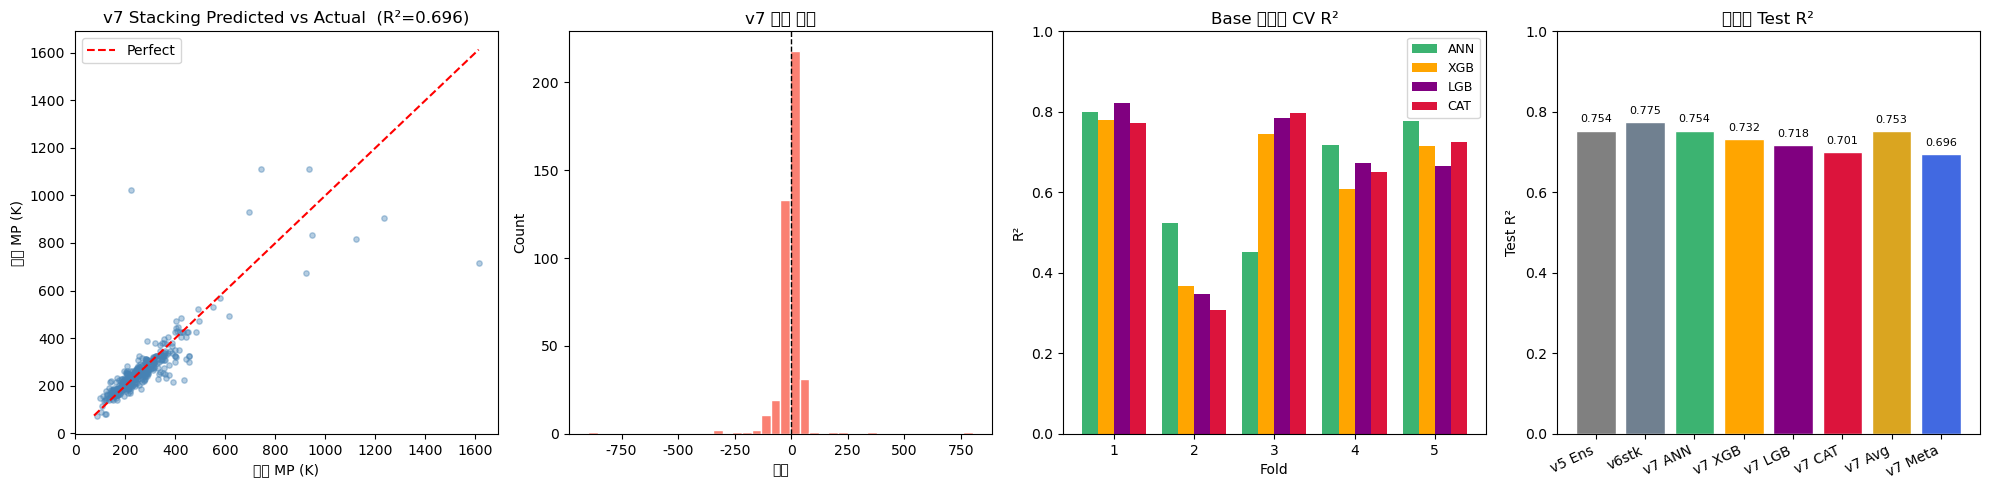

In [17]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

ax = axes[0]
ax.scatter(y_test, stack_pred, alpha=0.4, s=15, color="steelblue")
lims = [min(y_test.min(), stack_pred.min()), max(y_test.max(), stack_pred.max())]
ax.plot(lims, lims, "r--", linewidth=1.5, label="Perfect")
ax.set_xlabel("실제 MP (K)"); ax.set_ylabel("예측 MP (K)")
ax.set_title(f"v7 Stacking Predicted vs Actual  (R²={stack_r2:.3f})")
ax.legend()

ax = axes[1]
residuals = stack_pred - y_test
ax.hist(residuals, bins=40, color="salmon", edgecolor="white")
ax.axvline(0, color="k", linestyle="--", linewidth=1)
ax.set_xlabel("잔차"); ax.set_ylabel("Count"); ax.set_title("v7 잔차 분포")

ax = axes[2]
x_pos = np.arange(1, 6); w = 0.2
ax.bar(x_pos - 1.5*w, strat_r2, w, label="ANN", color="mediumseagreen")
ax.bar(x_pos - 0.5*w, xgb_r2_cv, w, label="XGB", color="orange")
ax.bar(x_pos + 0.5*w, lgb_r2_cv, w, label="LGB", color="purple")
ax.bar(x_pos + 1.5*w, cat_r2_cv, w, label="CAT", color="crimson")
ax.set_xlabel("Fold"); ax.set_ylabel("R²"); ax.set_title("Base 모델별 CV R²")
ax.set_ylim(0, 1); ax.legend(fontsize=9)

ax = axes[3]
labels = ["v5 Ens", "v6stk", "v7 ANN", "v7 XGB", "v7 LGB", "v7 CAT", "v7 Avg", "v7 Meta"]
vals = [0.7536, 0.7754, ann_test_r2, xgb_test_r2, lgb_test_r2, cat_test_r2, avg_r2, stack_r2]
colors = ["gray", "slategray", "mediumseagreen", "orange", "purple", "crimson", "goldenrod", "royalblue"]
ax.bar(labels, vals, color=colors, edgecolor="white")
ax.set_ylabel("Test R²"); ax.set_title("버전별 Test R²")
ax.set_ylim(0, 1)
for i, v in enumerate(vals):
    ax.text(i, v + 0.02, f"{v:.3f}", ha="center", fontsize=8)
plt.xticks(rotation=25, ha="right")

plt.tight_layout()
plt.show()

## 16. 결과 요약 — v5 vs v6 vs v7

In [18]:
summary = pd.DataFrame({
    "버전": [
        "v5 single-seed Test", "v5 5-seed Ensemble",
        "v6_stacking Meta (Ridge)",
        "v7 ANN Test", "v7 XGB Test", "v7 LGB Test", "v7 CAT Test",
        "v7 Simple Average", "v7 LightGBM Meta",
    ],
    "R²": [
        "0.7895", "0.7536", "0.7754",
        f"{ann_test_r2:.4f}", f"{xgb_test_r2:.4f}", f"{lgb_test_r2:.4f}", f"{cat_test_r2:.4f}",
        f"{avg_r2:.4f}", f"{stack_r2:.4f}",
    ],
    "MAE (K)": [
        "36.00", "32.00", "29.70",
        f"{ann_test_mae:.2f}", f"{xgb_test_mae:.2f}", f"{lgb_test_mae:.2f}", f"{cat_test_mae:.2f}",
        f"{avg_mae:.2f}", f"{stack_mae:.2f}",
    ],
})
print("=== v5 vs v6 vs v7 비교 ===")
print(f"노트북 전체 소요: {(time.time()-T0)/60:.1f}분")
print(f"v7 Meta feature importance (ANN, XGB, LGB, CAT): {meta.feature_importances_}")
print(f"v7 HPO: XGB best objective={study_xgb.best_value:.4f}, LGB best objective={study_lgb.best_value:.4f}")
summary

=== v5 vs v6 vs v7 비교 ===
노트북 전체 소요: 4.8분
v7 Meta feature importance (ANN, XGB, LGB, CAT): [236 131 140 154]
v7 HPO: XGB best objective=0.6041, LGB best objective=0.6072


,버전,R²,MAE (K)
0,v5 single-seed Test,0.7895,36.00
1,v5 5-seed Ensemble,0.7536,32.00
2,v6_stacking Meta (Ridge),0.7754,29.70
3,v7 ANN Test,0.7536,32.00
4,v7 XGB Test,0.7315,31.64
5,v7 LGB Test,0.7185,32.93
6,v7 CAT Test,0.7009,30.72
7,v7 Simple Average,0.7533,30.01
8,v7 LightGBM Meta,0.6960,32.40
